## Download Tiles

#### Dependencies

In [1]:
import os

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from owslib.wms import WebMapService

from detect_wildlife_crossings.wms.helpers import download_images_parallel

#### Config

In [2]:
output_dir = "D:/cassda-data/street-tiles/DE"
box_source = "../data/geodata/DE_Export_Box_on_Highway.json"
buffer_size = 640  # meter buffer around each point, square bbox

WMS_URL = "https://image.discomap.eea.europa.eu/arcgis/services/GioLand/VHR_2021_LAEA/ImageServer/WMSServer/?request=GetCapabilities&service=WMS"
CRS = "EPSG:3035"  # ETRS89 / ETRS-LAEA
PIXEL_RESOLUTION_M = 2  # 2 meters per pixel

#### Setup

In [4]:
gdf = gpd.read_file(box_source)

In [5]:
wms = WebMapService(
    WMS_URL,
    version="1.3.0",
)
layer_name = list(wms.contents)[0]
print(layer_name)

VHR_2021_LAEA


#### Plot Dataset

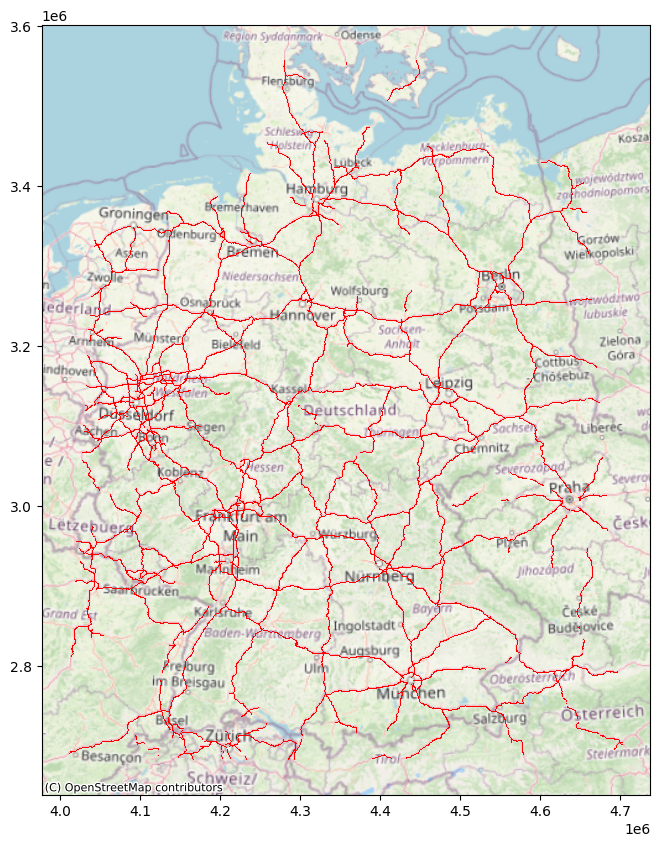

In [6]:
# Plot Dataset on Europe Map
gdf.plot(figsize=(10, 10), color="red", markersize=5)
ctx.add_basemap(
    plt.gca(),
    crs="EPSG:3035",
    source=ctx.providers.OpenStreetMap.Mapnik,
)

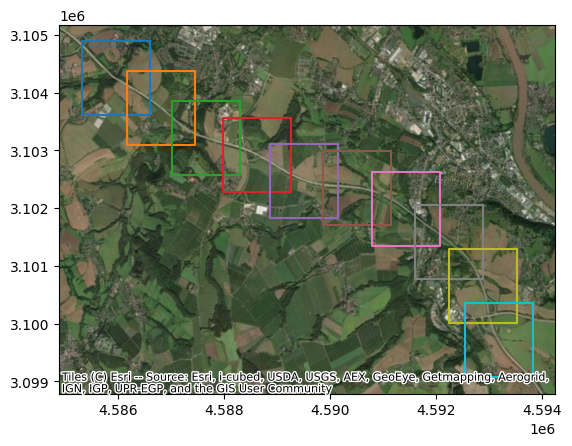

In [7]:
for geom in gdf.geometry.iloc[10:20]:
    bbox = geom.bounds  # minx, miny, maxx, maxy
    plt.plot(*geom.exterior.xy)
ctx.add_basemap(
    plt.gca(),
    crs="EPSG:3035",
    source=ctx.providers.Esri.WorldImagery,
)
plt.show()

In [8]:
# for every point create a square around it and request a WMS crop centered on the point
img_format = "image/jpeg"
img_size = (
    int(buffer_size * 2 / PIXEL_RESOLUTION_M),
    int(buffer_size * 2 / PIXEL_RESOLUTION_M),
)  # width, height in pixels

In [ ]:
# Multi-threaded version (NEW)
image_output_dir = os.path.join(output_dir, "images")
os.makedirs(image_output_dir, exist_ok=True)

# Download with 20 parallel threads
# Set limit=None to download all, or limit=100 to download first 100, etc.
results = download_images_parallel(
    gdf=gdf,
    wms=wms,
    layer_name=layer_name,
    img_size=img_size,
    img_format=img_format,
    image_output_dir=image_output_dir,
    crs=CRS,
    max_workers=20,  # Number of parallel threads
    limit=None,  # None = download all, or set a number like 100
)

Starting parallel download of 18784 images using 20 threads...
Progress: 1/18784 (0.0%) - Rate: 0.64 img/s - ETA: 29199s
Progress: 2/18784 (0.0%) - Rate: 1.27 img/s - ETA: 14741s
Progress: 3/18784 (0.0%) - Rate: 1.88 img/s - ETA: 9986s
Progress: 4/18784 (0.0%) - Rate: 2.49 img/s - ETA: 7547s
Progress: 5/18784 (0.0%) - Rate: 3.10 img/s - ETA: 6063s
Progress: 6/18784 (0.0%) - Rate: 3.65 img/s - ETA: 5139s
Progress: 7/18784 (0.0%) - Rate: 4.22 img/s - ETA: 4454s
Progress: 8/18784 (0.0%) - Rate: 4.81 img/s - ETA: 3908s
Progress: 9/18784 (0.0%) - Rate: 5.41 img/s - ETA: 3474s
Progress: 10/18784 (0.1%) - Rate: 5.83 img/s - ETA: 3219s
Progress: 11/18784 (0.1%) - Rate: 6.10 img/s - ETA: 3079s
Progress: 12/18784 (0.1%) - Rate: 6.58 img/s - ETA: 2852s
Progress: 13/18784 (0.1%) - Rate: 7.08 img/s - ETA: 2650s
Progress: 14/18784 (0.1%) - Rate: 7.61 img/s - ETA: 2466s
Progress: 15/18784 (0.1%) - Rate: 8.12 img/s - ETA: 2313s
Progress: 16/18784 (0.1%) - Rate: 8.54 img/s - ETA: 2197s
Progress: 17/187